# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [120]:
# filter dplyr warnings
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [121]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(raw_data.shape[0])

7214


In [122]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [123]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# type conversions
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# derived factors
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

race_order = ["Caucasian"] + [x for x in df["race"].dropna().unique() if x != "Caucasian"]
df["race_factor"] = pd.Categorical(df["race"], categories=race_order)

df["gender_factor"] = pd.Categorical(df["sex"], categories=["Male", "Female"])

df["score_factor"] = pd.Categorical(
    ["HighScore" if x != "Low" else "LowScore" for x in df["score_text"]],
    categories=["LowScore", "HighScore"]
)

print(df.shape[0])

6172


In [124]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [125]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


Higher COMPAS scores are slightly correlated with a longer length of stay.

In [126]:
df["length_of_stay"] = (
    df["c_jail_out"].dt.date - df["c_jail_in"].dt.date
).apply(lambda x: x.days)

print(df["length_of_stay"].corr(df["decile_score"]))

0.2073296916147045


After filtering we have the following demographic breakdown:

In [127]:
print(df["age_cat"].value_counts(dropna=False))

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [128]:
print(df["race"].value_counts(dropna=False))

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [129]:
race_counts = df["race"].value_counts()

print("Black defendants: %.2f%%" % (race_counts["African-American"] / len(df) * 100))
print("White defendants: %.2f%%" % (race_counts["Caucasian"] / len(df) * 100))
print("Hispanic defendants: %.2f%%" % (race_counts["Hispanic"] / len(df) * 100))
print("Asian defendants: %.2f%%" % (race_counts["Asian"] / len(df) * 100))
print("Native American defendants: %.2f%%" % (race_counts["Native American"] / len(df) * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [130]:
print(df["score_text"].value_counts(dropna=False))

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [131]:
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [132]:
print(df["sex"].value_counts(dropna=False))

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [133]:
sex_counts = df["sex"].value_counts()

print("Men: %.2f%%" % (sex_counts["Male"] / len(df) * 100))
print("Women: %.2f%%" % (sex_counts["Female"] / len(df) * 100))

Men: 80.96%
Women: 19.04%


In [134]:
print(df[df["two_year_recid"] == 1].shape[0])

2809


In [135]:
recid_percent = df[df["two_year_recid"] == 1].shape[0] / len(df) * 100
print("Two-year recidivism rate: %.2f%%" % recid_percent)

Two-year recidivism rate: 45.51%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

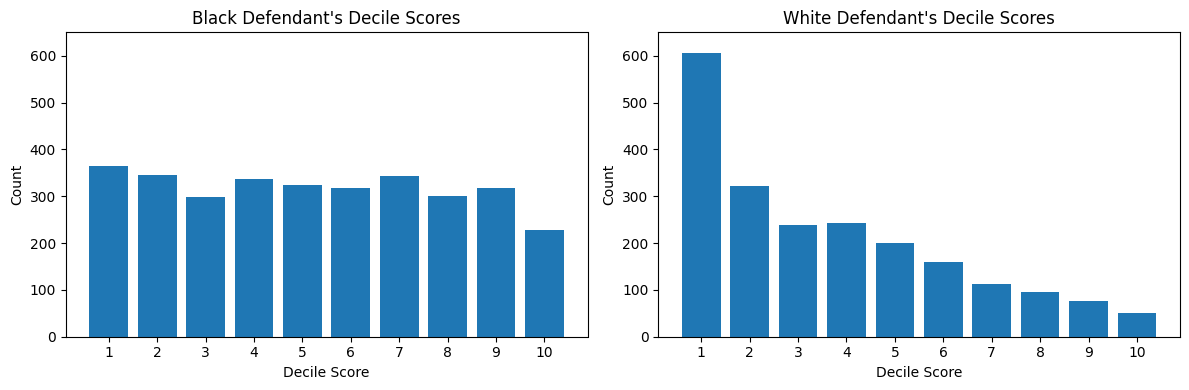

In [136]:
import matplotlib.pyplot as plt

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

black_counts = black_df["decile_score"].value_counts().sort_index()
white_counts = white_df["decile_score"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(black_counts.index.astype(str), black_counts.values)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

axes[1].bar(white_counts.index.astype(str), white_counts.values)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [137]:
print(pd.crosstab(df["decile_score"], df["race"]))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [138]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

df["score_binary"] = df["score_factor"].map({"LowScore": 0, "HighScore": 1}).astype(int)

model_glm = smf.glm(
    "score_binary ~ C(gender_factor, Treatment(reference='Male')) + C(age_factor, Treatment(reference='25 - 45')) + C(race_factor, Treatment(reference='Caucasian')) + priors_count + C(crime_factor, Treatment(reference='F')) + two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

print(model_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Mon, 06 Apr 2026   Deviance:                       6168.4
Time:                        14:12:10   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [139]:
import math

control = math.exp(-1.52554) / (1 + math.exp(-1.52554))
result = math.exp(0.47721) / (1 - control + (control * math.exp(0.47721)))

print(control)
print(result)

0.17864717443340628
1.4528408658138932


Women are 19.4% more likely than men to get a higher score.

In [140]:
result = math.exp(0.22127) / (1 - control + (control * math.exp(0.22127)))
print(result)

1.1947978508506671


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [141]:
result = math.exp(1.30839) / (1 - control + (control * math.exp(1.30839)))
print(result)

2.4961202077189455


In [142]:
df["pred_prob"] = model_glm.predict(df)

df["pred_class"] = pd.Categorical(
    ["Recid" if x >= 0.5 else "No Recid" for x in df["pred_prob"]],
    categories=["No Recid", "Recid"]
)

In [143]:
from sklearn.metrics import confusion_matrix

print("\n── Overall Confusion Matrix \n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.to_numpy().sum()

print("\nAccuracy  : %.3f" % ((TP + TN) / n))
print("Precision : %.3f" % (TP / (TP + FP)))
print("Recall    : %.3f" % (TP / (TP + FN)))
print("FPR       : %.3f" % (FP / (FP + TN)))
print("FNR       : %.3f" % (FN / (FN + TP)))


── Overall Confusion Matrix 

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [144]:
print("\n\n── Confusion Matrix by Race \n")

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = (
    df.groupby("race")
    .apply(lambda x: pd.Series({
        "n": len(x),
        "TP": ((x["pred"] == 1) & (x["actual"] == 1)).sum(),
        "TN": ((x["pred"] == 0) & (x["actual"] == 0)).sum(),
        "FP": ((x["pred"] == 1) & (x["actual"] == 0)).sum(),
        "FN": ((x["pred"] == 0) & (x["actual"] == 1)).sum()
    }))
    .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race 

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [145]:
print("\n\n── FPR and FNR Disparity by Race \n")

white_fpr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FPR"].iloc[0]
white_fnr = race_metrics.loc[race_metrics["race"] == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race 

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Assigment 2
Coding: Explaining the COMPAS Replacement Model




In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [147]:
features = [
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "sex",
    "priors_count",
    "days_b_screening_arrest"
]

target = "two_year_recid"

numeric_features = [
    "age",
    "priors_count",
    "days_b_screening_arrest"
]

category_features = [
    "c_charge_degree",
    "race",
    "age_cat",
    "sex"
]

X = df[features].copy()
y = df[target].astype(int)

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 7), Test: (1235, 7)


In [149]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# logistic regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# gradient-boosted tree
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['c_charge_degree', 'race',
                                                   'age_cat', 'sex'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [150]:
def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"],
            gdf["pred"],
            labels=[0, 1]
        ).ravel()

        if len(gdf["actual"].unique()) > 1:
            auc = round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)
        else:
            auc = np.nan

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan,
            "AUC": auc
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

In [151]:
print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\nGradient-Boosted Tree")
print(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.696  0.316  0.294  0.749
2         Caucasian  427     0.670  0.162  0.609  0.671
3          Hispanic   94     0.628  0.102  0.667  0.618
5             Other   65     0.785  0.085  0.556  0.730
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

Gradient-Boosted Tree
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.683  0.349  0.288  0.733
2         Caucasian  427     0.703  0.139  0.559  0.692
3          Hispanic   94     0.649  0.143  0.578  0.630
5             Other   65     0.723  0.085  0.778  0.638
1             Asian    7     0.714  0.167  1.000  0.833
4   Native American    1     1.000  0.000    NaN    NaN


In [152]:
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_cases = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_cases = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_low_idx = black_cases.index[0]
black_high_idx = black_cases.index[-1]

white_low_idx = white_cases.index[0]
white_high_idx = white_cases.index[-1]

selected_people = [
    ("Black lowest-risk", black_low_idx),
    ("Black highest-risk", black_high_idx),
    ("White lowest-risk", white_low_idx),
    ("White highest-risk", white_high_idx),
]

for label, idx in selected_people:
    print(label, "->", X_test_copy.loc[idx, "pred_prob"])

Black lowest-risk -> 0.029706176469428542
Black highest-risk -> 0.9969799024855189
White lowest-risk -> 0.03339927683182309
White highest-risk -> 0.9912243814922821


In [153]:
!pip install lime

In [154]:
from lime.lime_tabular import LimeTabularExplainer

X_train_enc = preprocessor.fit_transform(X_train)

feature_names = numeric_features + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
)

explainer = LimeTabularExplainer(
    training_data=X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

In [155]:
for label, idx in selected_people:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    row_enc_array = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc_array,
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {X_test_copy.loc[idx, 'pred_prob']:.3f}")

    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")


LIME: Black lowest-risk
Predicted probability: 0.030
days_b_screening_arrest <= 0.15               -0.3816
-0.69 < priors_count <= -0.48                 -0.1755
race_Asian <= 0.00                            +0.1403
race_Other <= 0.00                            +0.0553
-0.81 < age <= -0.29                          +0.0549
sex_Female <= 0.00                            +0.0490

LIME: Black highest-risk
Predicted probability: 0.997
days_b_screening_arrest > 0.15                +0.3825
age <= -0.81                                  +0.1811
-0.48 < priors_count <= 0.16                  -0.0523
sex_Female <= 0.00                            +0.0443
race_Other <= 0.00                            +0.0421
race_Hispanic <= 0.00                         +0.0403

LIME: White lowest-risk
Predicted probability: 0.033
days_b_screening_arrest <= 0.15               -0.3765
-0.69 < priors_count <= -0.48                 -0.1784
-0.29 < age <= 0.56                           -0.0988
sex_Female <= 0.00         

In [156]:
!pip install shap

In [157]:
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)
feat_names = numeric_features + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
)

# make sure SHAP gets dense data
if hasattr(X_test_enc, "toarray"):
    X_test_enc_dense = X_test_enc.toarray()
else:
    X_test_enc_dense = X_test_enc

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc_dense, max_samples=100)
)

shap_values = explainer_shap(X_test_enc_dense, check_additivity=False)

 96%|=================== | 1183/1235 [00:12<00:00]       

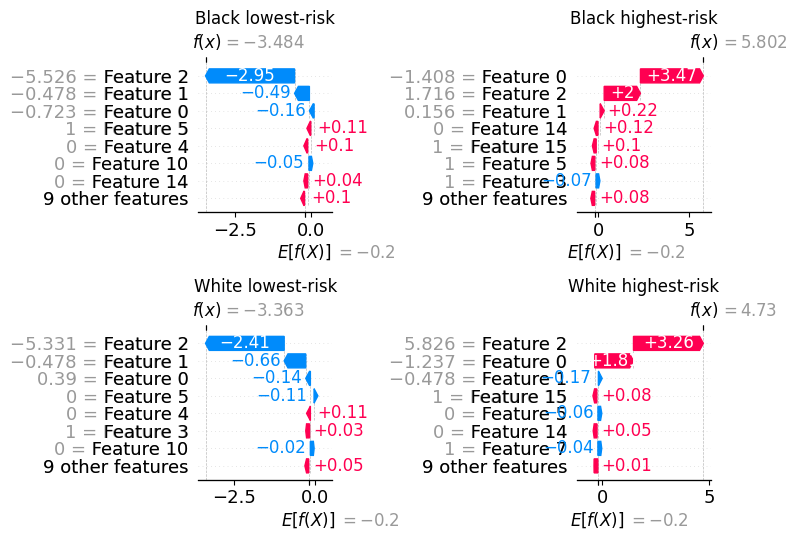

In [158]:
locations = [X_test.index.get_loc(idx) for _, idx in selected_people]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (label, idx), loc in zip(axes.flatten(), selected_people, locations):
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

In [159]:
!pip install dice-ml

In [160]:
import dice_ml
from dice_ml import Dice

dice_train = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)

dice_data = dice_ml.Data(
    dataframe=dice_train,
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

In [161]:
for label, idx in selected_people:
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "age": [18, 70],
            "priors_count": [0, 38]
        },
        features_to_vary=["age", "priors_count", "c_charge_degree"]
    )

    print(f"\nDiCE counterfactuals: {label}")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  2.92it/s]


DiCE counterfactuals: Black lowest-risk
Query instance (original outcome : 0)


,age,c_charge_degree,race,age_cat,sex,priors_count,days_b_screening_arrest,two_year_recid
0,26,F,African-American,25 - 45,Male,1,-30.0,0



Diverse Counterfactual set (new outcome: 1)


,age,c_charge_degree,race,age_cat,sex,priors_count,days_b_screening_arrest,two_year_recid
0,56,M,-,-,-,-,-,1
1,62,-,-,-,-,-,-,1
2,46,-,-,-,-,27,-,1


...

100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


DiCE counterfactuals: White highest-risk
Query instance (original outcome : 1)


,age,c_charge_degree,race,age_cat,sex,priors_count,days_b_screening_arrest,two_year_recid
0,20,F,Caucasian,Less than 25,Male,1,28.0,1



Diverse Counterfactual set (new outcome: 0)


,age,c_charge_degree,race,age_cat,sex,priors_count,days_b_screening_arrest,two_year_recid
0,56,-,-,-,-,13,-,0
1,57,-,-,-,-,-,-,0
2,69,-,-,-,-,8,-,0


In [162]:
summary_rows = []

for label, idx in selected_people:
    summary_rows.append({
        "person": label,
        "race": X_test.loc[idx, "race"],
        "pred_prob": round(X_test_copy.loc[idx, "pred_prob"], 3),
        "actual": int(y_test.loc[idx])
    })

pd.DataFrame(summary_rows)

,person,race,pred_prob,actual
0,Black lowest-risk,African-American,0.030,1
1,Black highest-risk,African-American,0.997,1
2,White lowest-risk,Caucasian,0.033,0
3,White highest-risk,Caucasian,0.991,1


Governance Memo

To the court auditor,

For this assignment, I used SHAP, LIME, and DiCE to better understand how the COMPAS replacement model was making its predictions. I followed the same workflow we used in class and then checked a few individual defendants more closely. What stood out to me was that the model could give the same final prediction, but each explanation method highlighted it in a different way. That made the exercise useful, because it showed that interpretation depends on the tool and not only on the model itself.

From my results, SHAP was the most helpful for seeing which features pushed the prediction up or down. LIME was easier to read at first, but it felt more limited because it only explains one local case at a time. DiCE was interesting because it showed the kinds of changes that might flip a prediction, so it made me think more about recourse and whether those changes are realistic in practice. Even so, I do not think these methods prove the model is fair. They help us inspect the model, but fairness still needs to be checked with outcome measures like false positives, false negatives, and differences across racial groups.

My recommendation would be to keep auditing the model over time instead of treating explanations as enough on their own. I would look at error rates by racial group, track which variables appear most often in explanations, and watch for features that may act as proxies for race. I would also keep checking whether the counterfactual examples from DiCE actually make sense in real life. Overall, these tools were helpful for understanding the model better, but they should be used as part of a broader governance process and not as the only evidence that the system is trustworthy.

###Assigment 3 - Mon 6 Apr

In [163]:
!pip install solas-ai

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd


In [164]:
model = gbt_pipeline

In [165]:
# make a dataframe for the audit stuff
audit = X_test.copy()
audit["actual"] = y_test.values
audit["pred"] = model.predict(X_test)
audit["prob"] = model.predict_proba(X_test)[:, 1]

print("preview:")
print(audit.head())
print("\nsize:")
print(audit.shape)


preview:
      age c_charge_degree              race          age_cat   sex  \
6019   21               F          Hispanic     Less than 25  Male   
2839   50               F  African-American  Greater than 45  Male   
2808   24               F             Other     Less than 25  Male   
5770   52               F             Asian  Greater than 45  Male   
1885   35               F  African-American          25 - 45  Male   

      priors_count  days_b_screening_arrest  actual  pred      prob  
6019             4                     -1.0       1     1  0.596959  
2839             5                     29.0       0     1  0.942716  
2808             2                     -1.0       1     1  0.524771  
5770             0                     -1.0       0     1  0.648833  
1885             7                    -23.0       1     1  0.602807  

size:
(1235, 10)


In [166]:
# some helper functions

def sel_rate(data, col, group, pred_col="pred"):
    temp = data[data[col] == group]
    if len(temp) == 0:
        return np.nan
    return (temp[pred_col] == 1).mean()


def smd_calc(data, col, group, ref, score_col="prob"):
    g1 = data[data[col] == group][score_col].dropna()
    g0 = data[data[col] == ref][score_col].dropna()

    m1 = g1.mean()
    m0 = g0.mean()

    v1 = g1.var(ddof=1)
    v0 = g0.var(ddof=1)

    pooled = np.sqrt((v1 + v0) / 2)

    if pooled == 0:
        return np.nan

    return (m1 - m0) / pooled


def make_table(data, col, ref):
    out = []

    ref_sr = sel_rate(data, col, ref)

    for g in sorted(data[col].dropna().unique()):
        sr = sel_rate(data, col, g)

        if g == ref:
            air = 1.0
            me = 0.0
            smd = 0.0
        else:
            air = sr / ref_sr if ref_sr != 0 else np.nan
            me = sr - ref_sr
            smd = smd_calc(data, col, g, ref)

        out.append({
            "group_type": col,
            "group": g,
            "ref_group": ref,
            "n": int((data[col] == g).sum()),
            "selection_rate": sr,
            "AIR_manual": air,
            "ME_manual": me,
            "SMD_manual": smd
        })

    return pd.DataFrame(out).sort_values("n", ascending=False)


def check_solas(names, **kwargs):
    for name in names:
        if hasattr(sd, name):
            print(f"\nrunning solas_disparity.{name}()")
            return getattr(sd, name)(**kwargs)
    return None


In [167]:
# task 1
# race and sex separately

race_manual = make_table(audit, "race", "Caucasian")
sex_manual = make_table(audit, "sex", "Male")

print("\n--------------------")
print("manual race results")
print("--------------------")
print(race_manual.round(4))

print("\n--------------------")
print("manual sex results")
print("--------------------")
print(sex_manual.round(4))


--------------------
manual race results
--------------------
  group_type             group  ref_group    n  selection_rate  AIR_manual  \
0       race  African-American  Caucasian  641          0.5398      2.1341   
2       race         Caucasian  Caucasian  427          0.2529      1.0000   
3       race          Hispanic  Caucasian   94          0.2766      1.0936   
5       race             Other  Caucasian   65          0.1231      0.4866   
1       race             Asian  Caucasian    7          0.1429      0.5648   
4       race   Native American  Caucasian    1          0.0000      0.0000   

   ME_manual  SMD_manual  
0     0.2869      0.6880  
2     0.0000      0.0000  
3     0.0237     -0.0069  
5    -0.1299     -0.2507  
1    -0.1101     -0.7435  
4    -0.2529         NaN  

--------------------
manual sex results
--------------------
  group_type   group ref_group     n  selection_rate  AIR_manual  ME_manual  \
1        sex    Male      Male  1002          0.4461      1.

In [168]:
race_dummies = pd.get_dummies(audit["race"])
race_solas_df = pd.concat([race_dummies, audit[["pred", "prob"]]], axis=1)

sex_dummies = pd.get_dummies(audit["sex"])
sex_solas_df = pd.concat([sex_dummies, audit[["pred", "prob"]]], axis=1)

print(race_solas_df.head())
print(sex_solas_df.head())

      African-American  Asian  Caucasian  Hispanic  Native American  Other  \
6019             False  False      False      True            False  False   
2839              True  False      False     False            False  False   
2808             False  False      False     False            False   True   
5770             False   True      False     False            False  False   
1885              True  False      False     False            False  False   

      pred      prob  
6019     1  0.596959  
2839     1  0.942716  
2808     1  0.524771  
5770     1  0.648833  
1885     1  0.602807  
      Female  Male  pred      prob
6019   False  True     1  0.596959
2839   False  True     1  0.942716
2808   False  True     1  0.524771
5770   False  True     1  0.648833
1885   False  True     1  0.602807


In [169]:
race_groups = [c for c in race_dummies.columns if c != "Caucasian"]

race_air_solas = sd.adverse_impact_ratio(
    group_data=race_solas_df,
    protected_groups=race_groups,
    reference_groups=["Caucasian"] * len(race_groups),
    group_categories=["race"] * len(race_groups),
    outcome=race_solas_df["pred"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0
)

print(race_air_solas)

+------------------------------+-----------------------------------------------------------+
|       Protected Groups       | African-American, Asian, Hispanic, Native American, Other |
|       Reference Groups       |   Caucasian, Caucasian, Caucasian, Caucasian, Caucasian   |
|       Group Categories       |               race, race, race, race, race                |
|        AIR Threshold         |                            0.8                            |
| Percent Difference Threshold |                            0.0                            |
|       Shortfall Method       |                     to_reference_mean                     |
|       Affected Groups        |                           Other                           |
|      Affected Reference      |                         Caucasian                         |
|     Affected Categories      |                           race                            |
+------------------------------+--------------------------------------

In [170]:

sex_groups = [c for c in sex_dummies.columns if c != "Male"]

sex_air_solas = sd.adverse_impact_ratio(
    group_data=sex_solas_df,
    protected_groups=sex_groups,
    reference_groups=["Male"] * len(sex_groups),
    group_categories=["sex"] * len(sex_groups),
    outcome=sex_solas_df["pred"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0
)

print(sex_air_solas)

+------------------------------+-------------------+
|       Protected Groups       |      Female       |
|       Reference Groups       |       Male        |
|       Group Categories       |        sex        |
|        AIR Threshold         |        0.8        |
| Percent Difference Threshold |        0.0        |
|       Shortfall Method       | to_reference_mean |
|       Affected Groups        |      Female       |
|      Affected Reference      |       Male        |
|     Affected Categories      |        sex        |
+------------------------------+-------------------+


In [171]:
# task 2
# race x sex

audit["race_sex"] = audit["race"].astype(str) + " x " + audit["sex"].astype(str)

inter_table = make_table(audit, "race_sex", "Caucasian x Male")
inter_table = inter_table.sort_values("AIR_manual", ascending=True)

print("\n--------------------")
print("intersection results")
print("--------------------")
print(inter_table.round(4))

worst_group = inter_table.iloc[0]

print("\nworst group:")
print(worst_group)

print("\nquick note:")
print(
    f"The group with the lowest AIR was {worst_group['group']}, "
    f"with an AIR of {round(worst_group['AIR_manual'], 4)}."
)




--------------------
intersection results
--------------------
  group_type                      group         ref_group    n  \
7   race_sex     Native American x Male  Caucasian x Male    1   
5   race_sex          Hispanic x Female  Caucasian x Male   18   
8   race_sex             Other x Female  Caucasian x Male   13   
9   race_sex               Other x Male  Caucasian x Male   52   
2   race_sex               Asian x Male  Caucasian x Male    7   
3   race_sex         Caucasian x Female  Caucasian x Male   86   
0   race_sex  African-American x Female  Caucasian x Male  116   
4   race_sex           Caucasian x Male  Caucasian x Male  341   
6   race_sex            Hispanic x Male  Caucasian x Male   76   
1   race_sex    African-American x Male  Caucasian x Male  525   

   selection_rate  AIR_manual  ME_manual  SMD_manual  
7          0.0000      0.0000    -0.2757         NaN  
5          0.0556      0.2015    -0.2201     -0.7516  
8          0.0769      0.2791    -0.1987    

In [172]:
# task 3
# fpr and fnr by race

race_rows = []

for race_name, temp in audit.groupby("race"):
    tn, fp, fn, tp = confusion_matrix(
        temp["actual"],
        temp["pred"],
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    race_rows.append({
        "race": race_name,
        "n": len(temp),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr
    })

race_errors = pd.DataFrame(race_rows).sort_values("n", ascending=False)

print("\n--------------------")
print("fpr and fnr by race")
print("--------------------")
print(race_errors.round(4))


ref_row = race_errors[race_errors["race"] == "Caucasian"].iloc[0]

ref_fpr_count = ref_row["FP"]
ref_fpr_total = ref_row["FP"] + ref_row["TN"]

ref_fnr_count = ref_row["FN"]
ref_fnr_total = ref_row["FN"] + ref_row["TP"]

test_rows = []

for _, row in race_errors.iterrows():
    race_name = row["race"]

    fpr_count = row["FP"]
    fpr_total = row["FP"] + row["TN"]

    fnr_count = row["FN"]
    fnr_total = row["FN"] + row["TP"]

    if race_name == "Caucasian":
        fpr_z, fpr_p = np.nan, np.nan
        fnr_z, fnr_p = np.nan, np.nan
    else:
        fpr_z, fpr_p = proportions_ztest(
            [fpr_count, ref_fpr_count],
            [fpr_total, ref_fpr_total]
        )

        fnr_z, fnr_p = proportions_ztest(
            [fnr_count, ref_fnr_count],
            [fnr_total, ref_fnr_total]
        )

    test_rows.append({
        "race": race_name,
        "n": row["n"],
        "FPR": row["FPR"],
        "FNR": row["FNR"],
        "delta_FPR_vs_ref": row["FPR"] - ref_row["FPR"],
        "delta_FNR_vs_ref": row["FNR"] - ref_row["FNR"],
        "FPR_z": fpr_z,
        "FPR_p": fpr_p,
        "FNR_z": fnr_z,
        "FNR_p": fnr_p
    })

race_tests = pd.DataFrame(test_rows).sort_values("n", ascending=False)

print("\n--------------------")
print("race disparity tests")
print("--------------------")
print(race_tests.round(4))


--------------------
fpr and fnr by race
--------------------
               race    n   TN   FP  FN   TP     FPR     FNR
0  African-American  641  198  106  97  240  0.3487  0.2878
2         Caucasian  427  229   37  90   71  0.1391  0.5590
3          Hispanic   94   42    7  26   19  0.1429  0.5778
5             Other   65   43    4  14    4  0.0851  0.7778
1             Asian    7    5    1   1    0  0.1667  1.0000
4   Native American    1    1    0   0    0  0.0000     NaN

--------------------
race disparity tests
--------------------
               race    n     FPR     FNR  delta_FPR_vs_ref  delta_FNR_vs_ref  \
0  African-American  641  0.3487  0.2878            0.2096           -0.2712   
1         Caucasian  427  0.1391  0.5590            0.0000            0.0000   
2          Hispanic   94  0.1429  0.5778            0.0038            0.0188   
3             Other   65  0.0851  0.7778           -0.0540            0.2188   
4             Asian    7  0.1667  1.0000            0

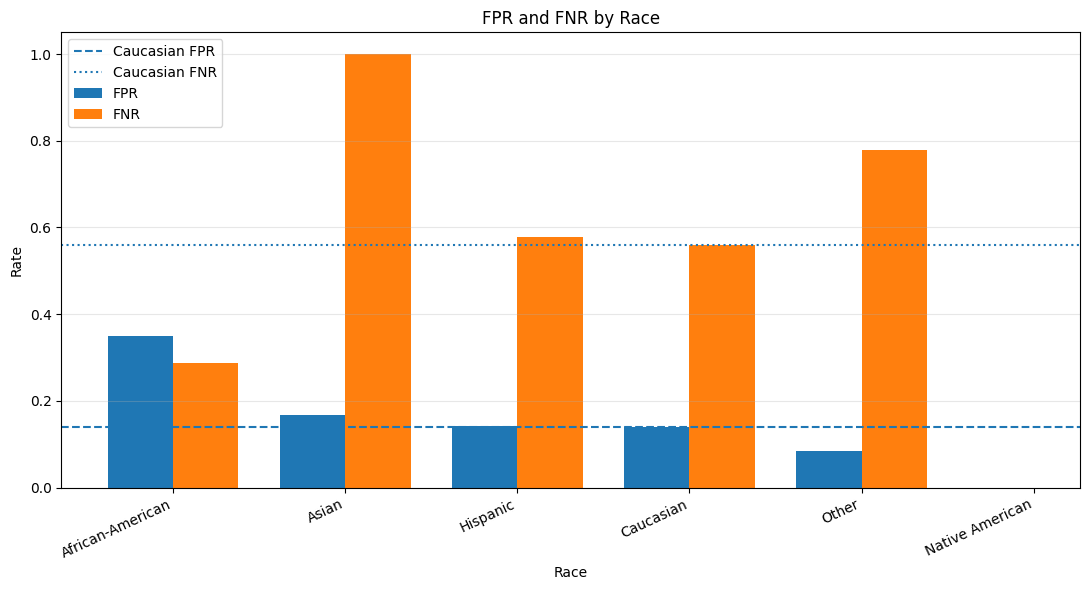

In [173]:
# task 4
# chart

plot_df = race_errors.copy().sort_values("FPR", ascending=False)

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width/2, plot_df["FPR"], width, label="FPR")
ax.bar(x + width/2, plot_df["FNR"], width, label="FNR")

ref_fpr = plot_df.loc[plot_df["race"] == "Caucasian", "FPR"].iloc[0]
ref_fnr = plot_df.loc[plot_df["race"] == "Caucasian", "FNR"].iloc[0]

ax.axhline(ref_fpr, linestyle="--", linewidth=1.5, label="Caucasian FPR")
ax.axhline(ref_fnr, linestyle=":", linewidth=1.5, label="Caucasian FNR")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["race"], rotation=25, ha="right")
ax.set_ylabel("Rate")
ax.set_xlabel("Race")
ax.set_title("FPR and FNR by Race")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("grouped_fpr_fnr_by_race.png", dpi=300, bbox_inches="tight")
plt.show()


In [174]:
lowest_race = race_manual.sort_values("AIR_manual").iloc[0]
lowest_sex = sex_manual.sort_values("AIR_manual").iloc[0]
lowest_inter = inter_table.iloc[0]

print("\n--------------------")
print("summary")
print("--------------------")

print("\nlowest race AIR:")
print(lowest_race)

print("\nlowest sex AIR:")
print(lowest_sex)

print("\nlowest intersection AIR:")
print(lowest_inter)

print("\nremember:")
print("AIR, ME, and SMD = practical significance")
print("z test p-values = statistical significance")


--------------------
summary
--------------------

lowest race AIR:
group_type                   race
group             Native American
ref_group               Caucasian
n                               1
selection_rate                0.0
AIR_manual                    0.0
ME_manual               -0.252927
SMD_manual                    NaN
Name: 4, dtype: object

lowest sex AIR:
group_type             sex
group               Female
ref_group             Male
n                      233
selection_rate    0.180258
AIR_manual        0.404067
ME_manual         -0.26585
SMD_manual       -0.653221
Name: 0, dtype: object

lowest intersection AIR:
group_type                      race_sex
group             Native American x Male
ref_group               Caucasian x Male
n                                      1
selection_rate                       0.0
AIR_manual                           0.0
ME_manual                       -0.27566
SMD_manual                           NaN
Name: 7, dtype: object

re